In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf

# Load the dataset
data = pd.read_csv('GDP.csv', parse_dates=['observation_date'], index_col='observation_date')

print(data)
# Extract the GDP column as a Series
gdp = data['GDP']

                        GDP
observation_date           
1947-01-01          243.164
1947-04-01          245.968
1947-07-01          249.585
1947-10-01          259.745
1948-01-01          265.742
...                     ...
2023-10-01        28296.967
2024-01-01        28624.069
2024-04-01        29016.714
2024-07-01        29374.914
2024-10-01        29723.864

[312 rows x 1 columns]


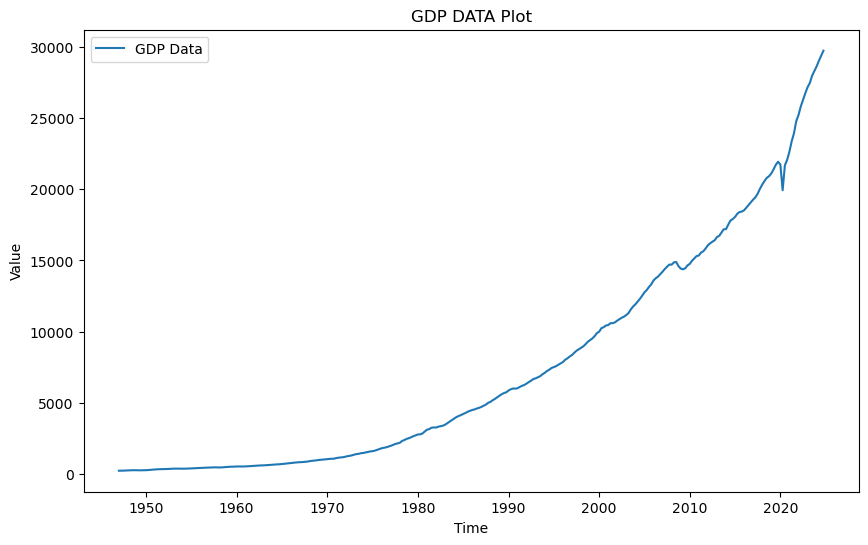

In [2]:
# Step 1: Visual Inspection
def plot_time_series(data):
    plt.figure(figsize=(10, 6))
    plt.plot(data, label='GDP Data')
    plt.title('GDP DATA Plot')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

# Plot the GDP time series
plot_time_series(gdp)

# TO CHECK STATIONARY DATA

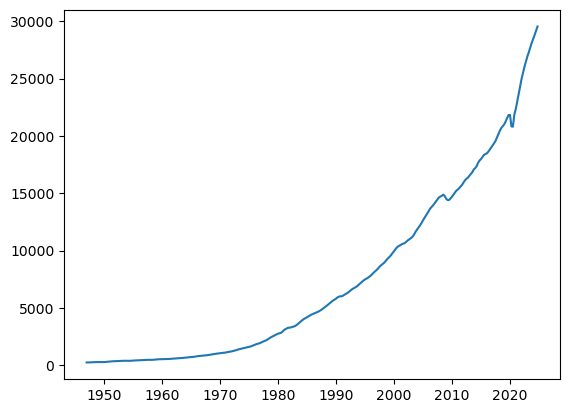

In [3]:
import matplotlib.pyplot as plt
plt.plot(data.rolling(window='120D').mean())
plt.show()

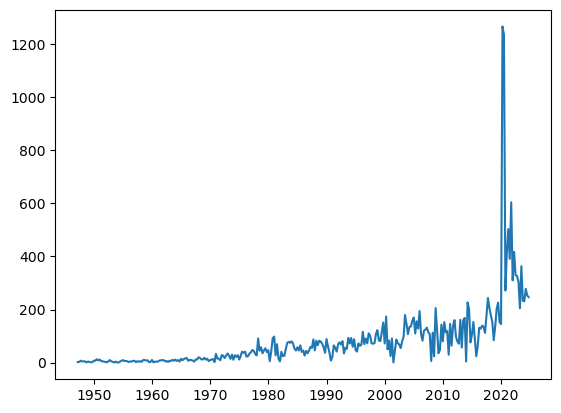

In [4]:
plt.plot(data.rolling(window='120D').std())
plt.show()

In [5]:
# Step 2: Statistical Tests
def adf_test(data):
    print("Augmented Dickey-Fuller (ADF) Test:")
    result = adfuller(data)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print(f'Critical Values: {result[4]}')
    if result[1] <= 0.05:
        print("Result: The data is stationary (reject the null hypothesis)")
    else:
        print("Result: The data is non-stationary (fail to reject the null hypothesis)")

def kpss_test(data):
    print("\nKwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:")
    result = kpss(data)
    print(f'KPSS Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print(f'Critical Values: {result[3]}')
    if result[1] <= 0.05:
        print("Result: The data is non-stationary (reject the null hypothesis)")
    else:
        print("Result: The data is stationary (fail to reject the null hypothesis)")

adf_test(gdp)
kpss_test(gdp)

Augmented Dickey-Fuller (ADF) Test:
ADF Statistic: 9.159156043710945
p-value: 1.0
Critical Values: {'1%': -3.451621854687657, '5%': -2.870908950689806, '10%': -2.571761810613944}
Result: The data is non-stationary (fail to reject the null hypothesis)

Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test:
KPSS Statistic: 2.426475105255299
p-value: 0.01
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Result: The data is non-stationary (reject the null hypothesis)


/var/folders/kp/7yh5fxwj1g36fg94lthhd7n00000gn/T/ipykernel_11983/3109518810.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(data)


# ACF/PACF detecting long-term dependencies.

# Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)

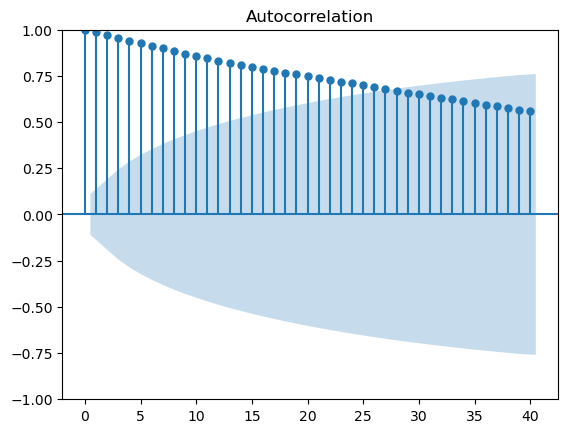

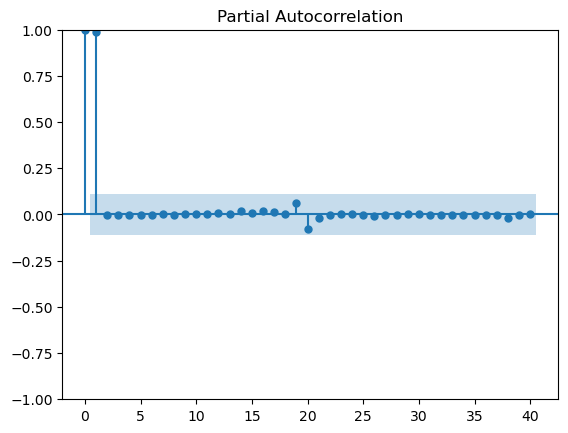

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF
plot_acf(data, lags=40)
plot_pacf(data, lags=40)
plt.show()

# Residual Analysis

/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


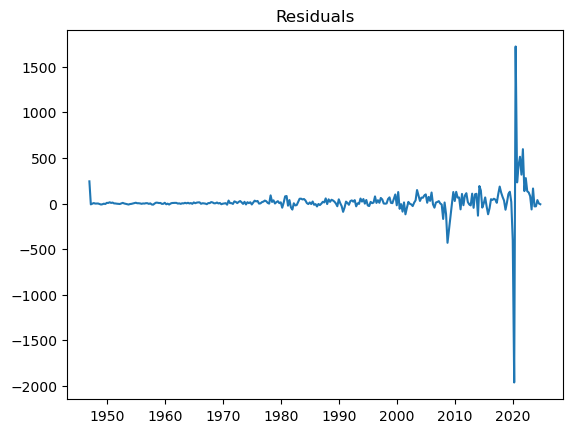

      lb_stat  lb_pvalue
1    4.651153   0.031033
2    5.409094   0.066901
3    6.020090   0.110637
4    6.133068   0.189429
5    7.918295   0.160796
6    9.954278   0.126591
7    9.959216   0.190896
8   11.126491   0.194635
9   11.406265   0.248886
10  11.751979   0.301999


In [7]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

# Fit a linear model (e.g., ARIMA)
model = ARIMA(data, order=(1, 1, 1))
results = model.fit()
residuals = results.resid

# Plot residuals
plt.plot(residuals)
plt.title('Residuals')
plt.show()

# Ljung-Box test
lb_test = acorr_ljungbox(residuals, lags=10)
print(lb_test)

# Non-Linearity Tests

### Linear Regression and Residual Analysis

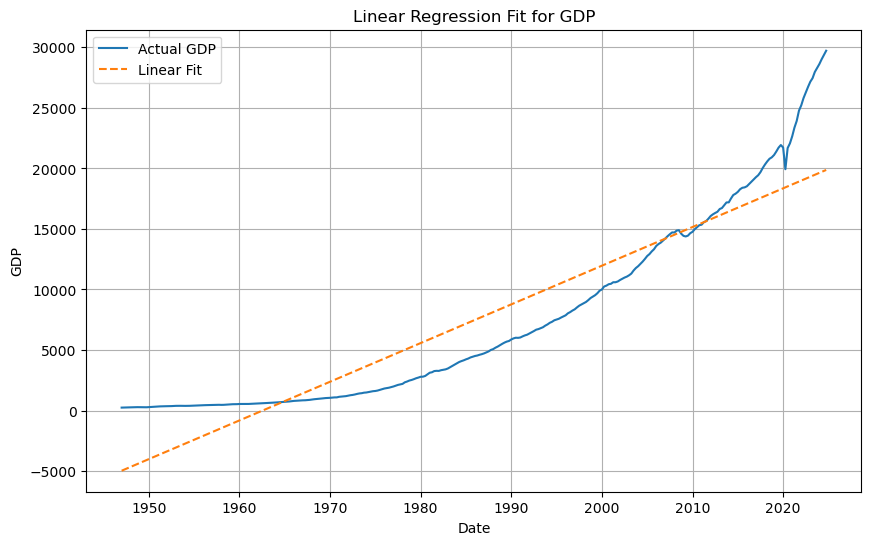

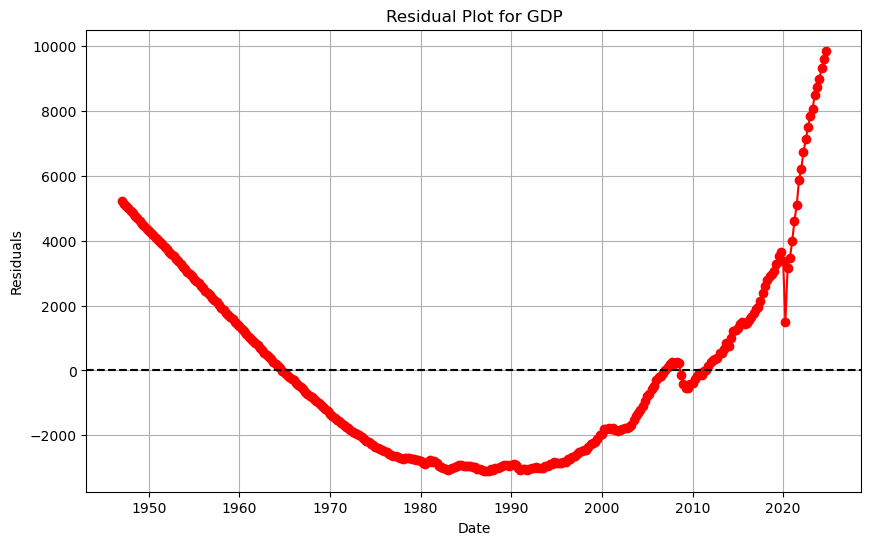

The data is likely non-linear.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Convert dates to numeric values (e.g., days since the start)
data['days'] = (data.index - data.index[0]).days

# Fit a linear regression model
X = data[['days']]  # Independent variable (days since start)
y = data['GDP']     # Dependent variable (GDP values)

model = LinearRegression()
model.fit(X, y)  # Fit the model
y_pred = model.predict(X)  # Predict GDP values

# Plot the linear fit
plt.figure(figsize=(10, 6))
plt.plot(data.index, y, label='Actual GDP')
plt.plot(data.index, y_pred, label='Linear Fit', linestyle='--')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.title('Linear Regression Fit for GDP')
plt.legend()
plt.grid(True)
plt.show()

# Residuals
residuals = y - y_pred  # Calculate residuals

# Plot residuals
plt.figure(figsize=(10, 6))
plt.plot(data.index, residuals, marker='o', color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.title('Residual Plot for GDP')
plt.grid(True)
plt.show()

# Check for patterns in residuals
if np.allclose(residuals, np.zeros_like(residuals), atol=1e-1):
    print("The data is likely linear.")
else:
    print("The data is likely non-linear.")

### Polynomial Regression

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Linear model
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)
mse_linear = mean_squared_error(y, y_pred_linear)

# Polynomial model (degree=2)
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_pred_poly = poly_model.predict(X_poly)
mse_poly = mean_squared_error(y, y_pred_poly)

print(f"Linear MSE: {mse_linear}")
print(f"Polynomial MSE: {mse_poly}")

if mse_poly < mse_linear:
    print("The data is likely non-linear.")
else:
    print("The data is likely linear.")

Linear MSE: 8514261.342109421
Polynomial MSE: 483192.0617735775
The data is likely non-linear.


### Detrending and Analyzing Seasonality

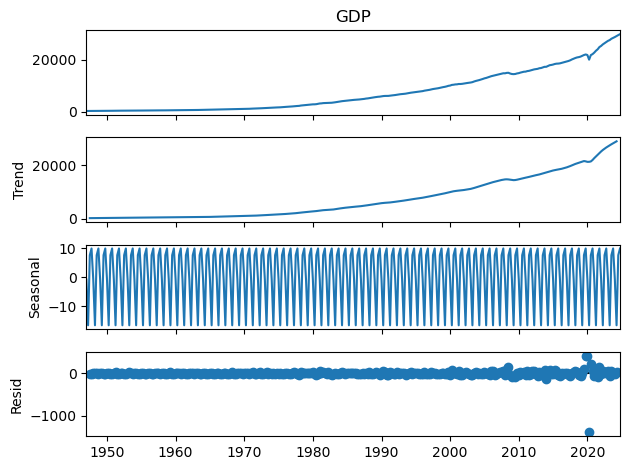

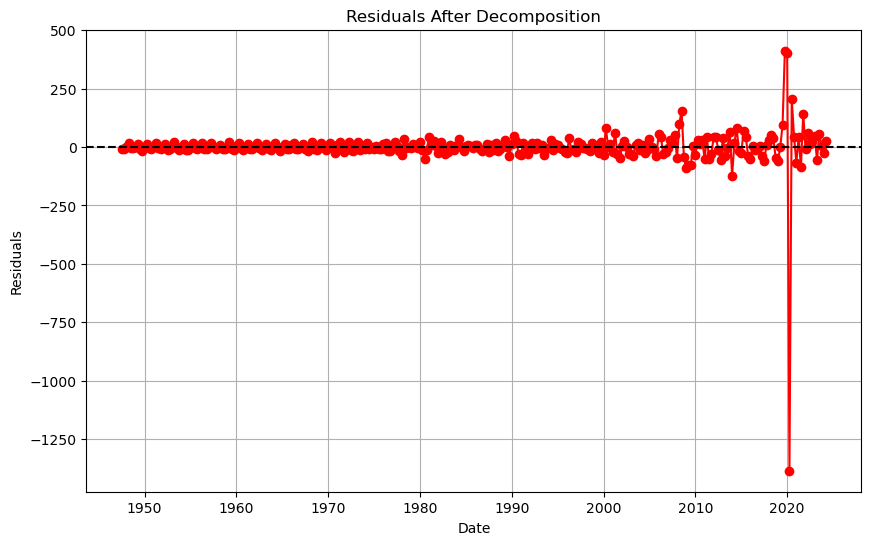

The data is likely non-linear.


In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series
decomposition = seasonal_decompose(data['GDP'], model='additive', period=4)  # Adjust period as needed

# Plot decomposition
decomposition.plot()
plt.show()

# Analyze residuals
residuals = decomposition.resid.dropna()
plt.figure(figsize=(10, 6))
plt.plot(residuals, marker='o', color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.title('Residuals After Decomposition')
plt.grid(True)
plt.show()

if np.allclose(residuals, np.zeros_like(residuals), atol=1e-1):
    print("The data is likely linear.")
else:
    print("The data is likely non-linear.")

### Advanced: Non-linearity Test (Ramsey RESET Test)

In [11]:
import statsmodels.api as sm

# Add a constant to the independent variable
X = sm.add_constant(data['days'])

# Fit linear model
model = sm.OLS(data['GDP'], X).fit()

# Ramsey RESET test
reset_test = sm.stats.diagnostic.linear_reset(model, power=2, test_type='fitted')
print(reset_test)

if reset_test.pvalue < 0.05:
    print("The data is likely non-linear.")
else:
    print("The data is likely linear.")

<Wald test (chi2): statistic=5135.846806976582, p-value=0.0, df_denom=1>
The data is likely non-linear.


# non-stationarity in time series data using the methods

### Differencing

Differencing is used to remove trends and make the data stationary.

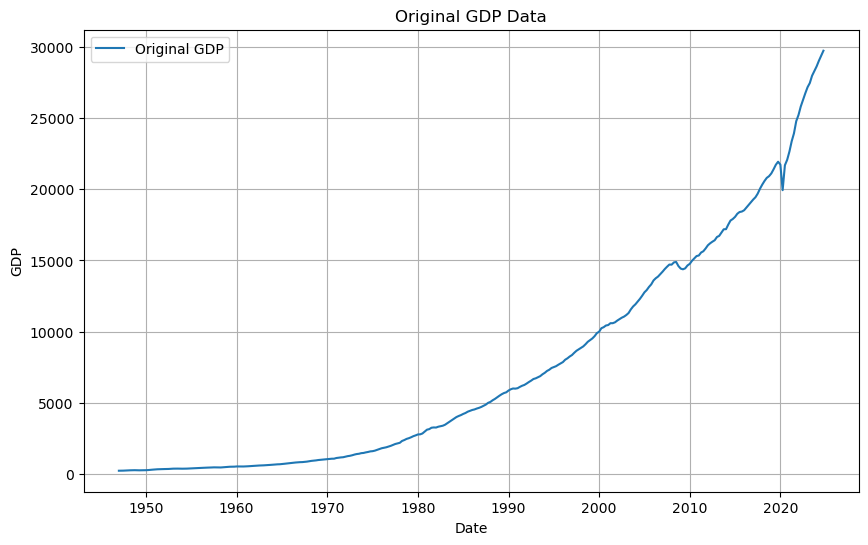

                        GDP   days  GDP_diff
observation_date                            
1947-01-01          243.164      0       NaN
1947-04-01          245.968     90     2.804
1947-07-01          249.585    181     3.617
1947-10-01          259.745    273    10.160
1948-01-01          265.742    365     5.997
...                     ...    ...       ...
2023-10-01        28296.967  28032   329.270
2024-01-01        28624.069  28124   327.102
2024-04-01        29016.714  28215   392.645
2024-07-01        29374.914  28306   358.200
2024-10-01        29723.864  28398   348.950

[312 rows x 3 columns]


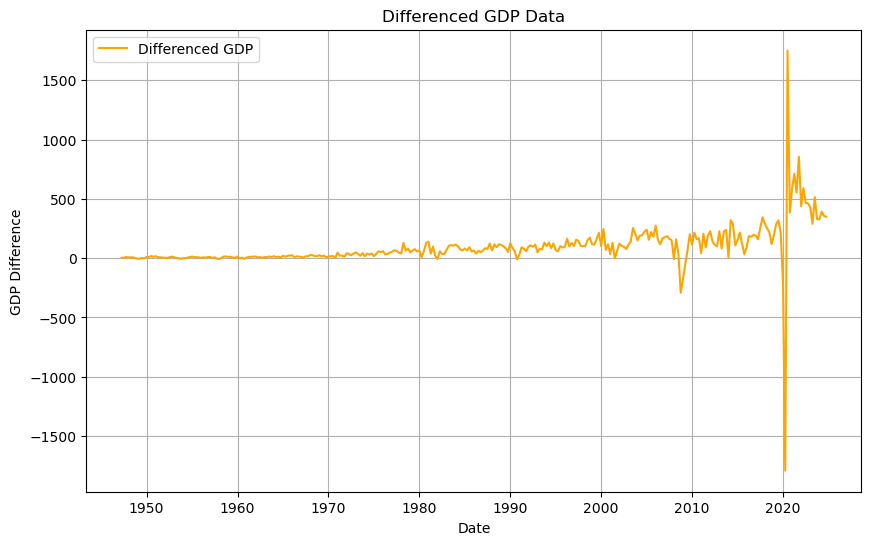

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Plot original data
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['GDP'], label='Original GDP')
plt.title('Original GDP Data')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.show()

# First-order differencing
data['GDP_diff'] = data['GDP'].diff()

print(data)

# Plot differenced data
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['GDP_diff'], label='Differenced GDP', color='orange')
plt.title('Differenced GDP Data')
plt.xlabel('Date')
plt.ylabel('GDP Difference')
plt.legend()
plt.grid(True)
plt.show()

### Detrending

Detrending removes trends (e.g., linear or polynomial) from the data.

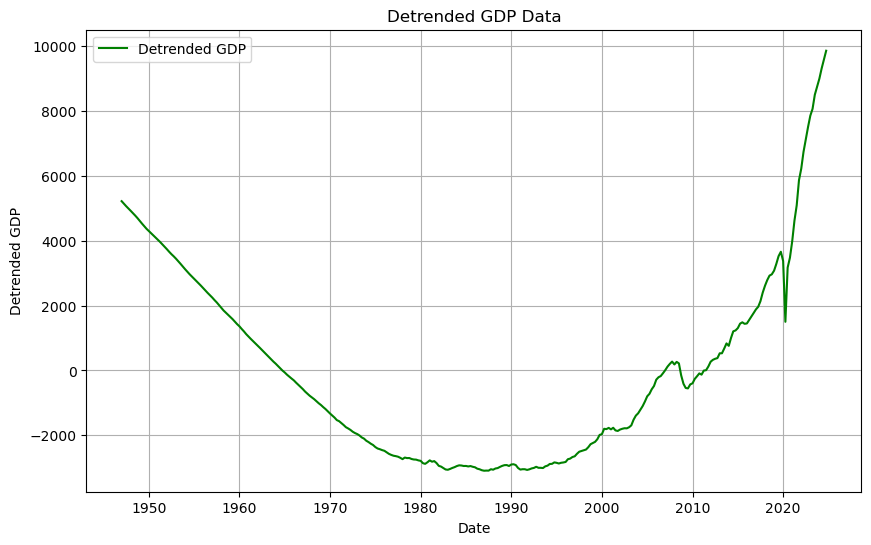

In [13]:
from scipy.signal import detrend

# Detrend the data (linear detrending)
data['GDP_detrended'] = detrend(data['GDP'], type='linear')

# Plot detrended data
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['GDP_detrended'], label='Detrended GDP', color='green')
plt.title('Detrended GDP Data')
plt.xlabel('Date')
plt.ylabel('Detrended GDP')
plt.legend()
plt.grid(True)
plt.show()

### ARIMA (AutoRegressive Integrated Moving Average)

/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/var/folders/kp/7yh5fxwj1g36fg94lth

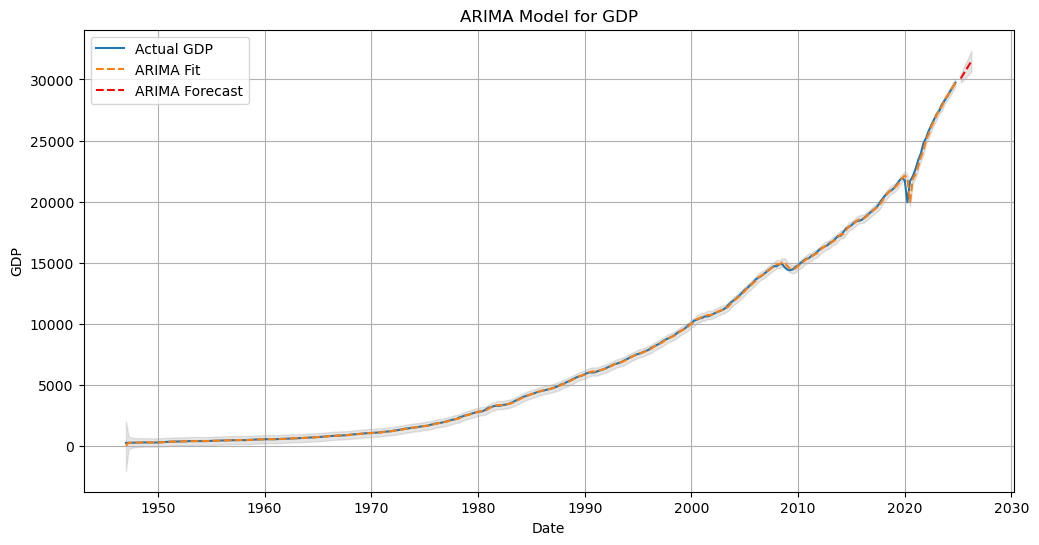

                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                  312
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2040.113
Date:                Sun, 07 Jun 2026   AIC                           4086.225
Time:                        15:35:42   BIC                           4097.445
Sample:                    01-01-1947   HQIC                          4090.710
                         - 10-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9985      0.004    279.626      0.000       0.991       1.005
ma.L1         -0.9256      0.011    -87.883      0.000      -0.946      -0.905
sigma2      2.899e+04    451.278     64.232      0.0

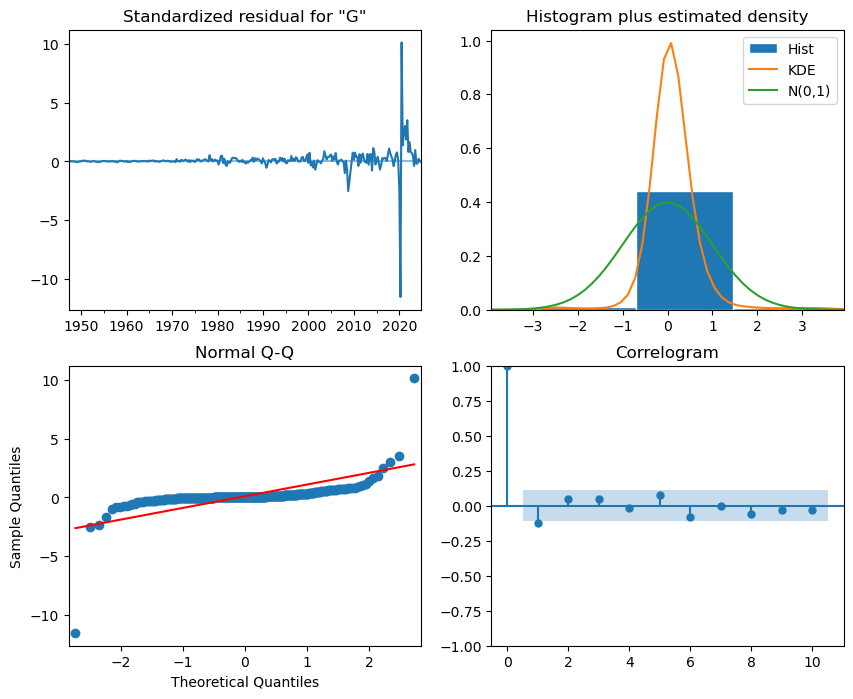

In [14]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 2. Fit ARIMA model
model = ARIMA(data['GDP'], order=(1, 1, 1))  # You might want to tune these parameters
results = model.fit()

# 3. Generate in-sample predictions
forecast = results.get_prediction(start=0, end=len(data)-1)
forecast_mean = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

# 4. Generate out-of-sample forecasts (next 5 periods)
forecast_steps = 5
future_forecast = results.get_forecast(steps=forecast_steps)
future_mean = future_forecast.predicted_mean
future_ci = future_forecast.conf_int()

# 5. Plot results
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['GDP'], label='Actual GDP')

# In-sample forecast
plt.plot(data.index, forecast_mean, label='ARIMA Fit', linestyle='--')
plt.fill_between(data.index, 
                confidence_intervals.iloc[:, 0],
                confidence_intervals.iloc[:, 1],
                color='gray', alpha=0.2)

# Out-of-sample forecast
future_index = pd.date_range(start=data.index[-1], periods=forecast_steps+1, freq='Q')[1:]  # adjust freq to your data frequency
plt.plot(future_index, future_mean, label='ARIMA Forecast', linestyle='--', color='red')
plt.fill_between(future_index,
                future_ci.iloc[:, 0],
                future_ci.iloc[:, 1],
                color='gray', alpha=0.2)

plt.title('ARIMA Model for GDP')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.show()

# 6. Print model summary and diagnostics
print(results.summary())

# 7. Plot diagnostics
results.plot_diagnostics(figsize=(10, 8))
plt.show()

RMSE for ARIMA Forecast: 170.1767
MSE for ARIMA Forecast: 28960.1056
R-squared for ARIMA Forecast: 0.9995
MAE for ARIMA Forecast: 52.5010


/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


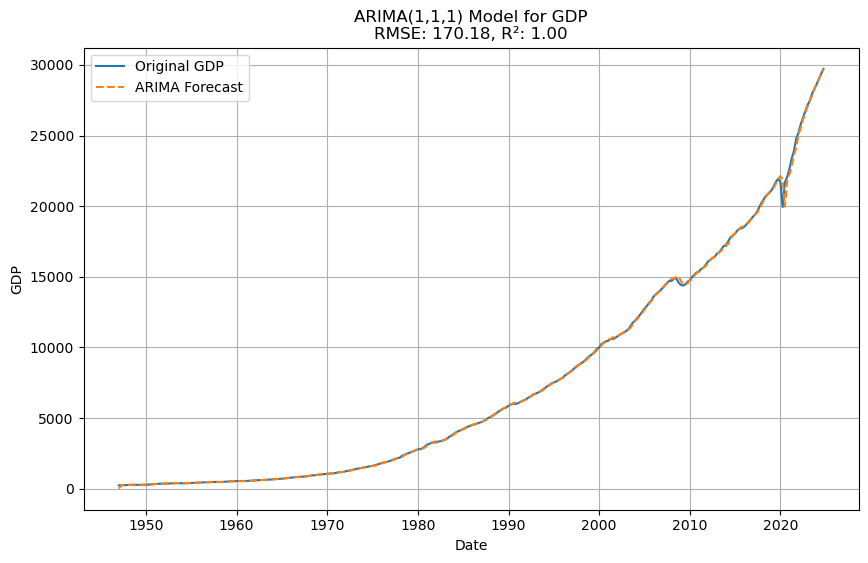

                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                  312
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2040.113
Date:                Sun, 07 Jun 2026   AIC                           4086.225
Time:                        15:35:42   BIC                           4097.445
Sample:                    01-01-1947   HQIC                          4090.710
                         - 10-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9985      0.004    279.626      0.000       0.991       1.005
ma.L1         -0.9256      0.011    -87.883      0.000      -0.946      -0.905
sigma2      2.899e+04    451.278     64.232      0.0

In [15]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Fit ARIMA model
model = ARIMA(data['GDP'], order=(1, 1, 1))
results = model.fit()

# Generate in-sample predictions
forecast = results.predict(start=0, end=len(data)-1)

# Calculate evaluation metrics
actual_values = data['GDP'].values[1:]  # Skip first value due to differencing (d=1)
predicted_values = forecast.values[1:]   # Skip first prediction

mse_forecast = mean_squared_error(actual_values, predicted_values)
rmse_forecast = np.sqrt(mse_forecast)
mae = mean_absolute_error(actual_values, predicted_values)
r_squared_forecast = r2_score(actual_values, predicted_values)

# Print metrics
print(f"RMSE for ARIMA Forecast: {rmse_forecast:.4f}")
print(f"MSE for ARIMA Forecast: {mse_forecast:.4f}")
print(f"R-squared for ARIMA Forecast: {r_squared_forecast:.4f}")
print(f"MAE for ARIMA Forecast: {mae:.4f}")

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['GDP'], label='Original GDP')
plt.plot(data.index, forecast, label='ARIMA Forecast', linestyle='--')
plt.title(f'ARIMA(1,1,1) Model for GDP\nRMSE: {rmse_forecast:.2f}, R²: {r_squared_forecast:.2f}')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.show()

print(results.summary())

### SARIMA (Seasonal ARIMA)

SARIMA extends ARIMA to handle seasonality.

/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.56503D+00    |proj g|=  5.37200D-02

At iterate    5    f=  6.55693D+00    |proj g|=  7.27438D-03

At iterate   10    f=  6.55608D+00    |proj g|=  7.37905D-03

At iterate   15    f=  6.53825D+00    |proj g|=  9.14053D-02

At iterate   20    f=  6.49259D+00    |proj g|=  3.69729D-03

At iterate   25    f=  6.49257D+00    |proj g|=  4.80228D-04

At iterate   30    f=  6.48892D+00    |proj g|=  2.10517D-02
  ys=-2.053E-03  -gs= 1.113E-03 BFGS update SKIPPED

At iterate   35    f=  6.48805D+00    |proj g|=  1.52716D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of 

/var/folders/kp/7yh5fxwj1g36fg94lthhd7n00000gn/T/ipykernel_11983/3290423111.py:17: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=last_date, periods=9, freq='Q')[1:]  # Starting from next quarter


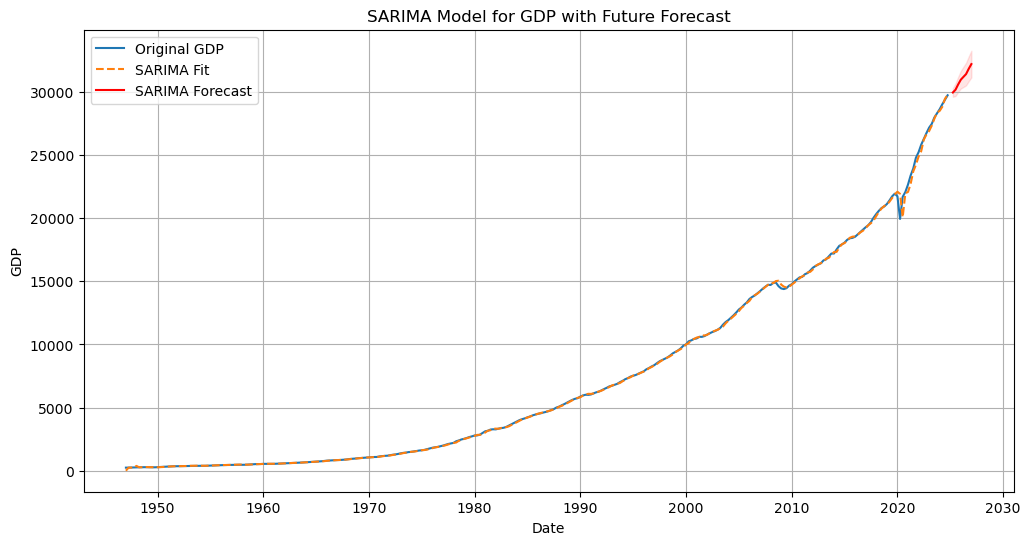

                                     SARIMAX Results                                     
Dep. Variable:                               GDP   No. Observations:                  312
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 4)   Log Likelihood               -2024.269
Date:                           Sun, 07 Jun 2026   AIC                           4058.539
Time:                                   15:35:43   BIC                           4077.173
Sample:                               01-01-1947   HQIC                          4065.990
                                    - 10-01-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9612      0.075    -12.874      0.000      -1.108      -0.815
ma.L1          0.9996      0.883      1.132

In [16]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Fit SARIMA model
model = SARIMAX(data['GDP'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 4))  # Seasonal period=4 (quarterly)
results = model.fit()

# In-sample prediction
forecast = results.predict(start=0, end=len(data) - 1)

# Additional forecast: predict next 8 periods (2 years for quarterly data)
future_forecast = results.get_forecast(steps=8)
future_ci = future_forecast.conf_int()

# Create future dates
last_date = data.index[-1]
future_dates = pd.date_range(start=last_date, periods=9, freq='Q')[1:]  # Starting from next quarter

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['GDP'], label='Original GDP')
plt.plot(data.index, forecast, label='SARIMA Fit', linestyle='--')
plt.plot(future_dates, future_forecast.predicted_mean, label='SARIMA Forecast', color='red')
plt.fill_between(future_dates,
                 future_ci.iloc[:, 0],
                 future_ci.iloc[:, 1], color='red', alpha=0.1)
plt.title('SARIMA Model for GDP with Future Forecast')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.show()

print(results.summary())

In [17]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Calculate RMSE for the SARIMA forecast
rmse_forecast = np.sqrt(mean_squared_error(data['GDP'], forecast))

# Print RMSE value
print(f"RMSE for SARIMA Forecast: {rmse_forecast}")

# RMSE for the original data (should be zero)
rmse_original = np.sqrt(mean_squared_error(data['GDP'], data['GDP']))
print(f"RMSE for Original GDP Data: {rmse_original}")

RMSE for SARIMA Forecast: 174.0903236262334
RMSE for Original GDP Data: 0.0


In [18]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Example data (replace with your actual data)
# data = pd.DataFrame({'GDP': [your_actual_GDP_values]})
# forecast = [your_forecasted_values]

# Calculate RMSE for the SARIMA forecast
rmse_forecast = np.sqrt(mean_squared_error(data['GDP'], forecast))

# Calculate MSE for the SARIMA forecast
mse_forecast = mean_squared_error(data['GDP'], forecast)

# Calculate R-squared for the SARIMA forecast
r_squared_forecast = r2_score(data['GDP'], forecast)

mae = mean_absolute_error(data['GDP'], forecast)

# Print RMSE, MSE, and R-squared values
print(f"RMSE for SARIMA Forecast: {rmse_forecast}")
print(f"MSE for SARIMA Forecast: {mse_forecast}")
print(f"R-squared for SARIMA Forecast: {r_squared_forecast}")
print(f"MAE for SARIMA Forecast: {mae}")

# Optional: Calculate RMSE, MSE, and R-squared for the original data (for demonstration purposes)
# RMSE and MSE will always be zero, and R-squared will be 1 since we're comparing the data with itself
rmse_original = np.sqrt(mean_squared_error(data['GDP'], data['GDP']))
mse_original = mean_squared_error(data['GDP'], data['GDP'])
r_squared_original = r2_score(data['GDP'], data['GDP'])

print(f"\nRMSE for Original GDP Data: {rmse_original}")
print(f"MSE for Original GDP Data: {mse_original}")
print(f"R-squared for Original GDP Data: {r_squared_original}")

RMSE for SARIMA Forecast: 174.0903236262334
MSE for SARIMA Forecast: 30307.440780286688
R-squared for SARIMA Forecast: 0.9994972967451675
MAE for SARIMA Forecast: 59.140444974014734

RMSE for Original GDP Data: 0.0
MSE for Original GDP Data: 0.0
R-squared for Original GDP Data: 1.0


# non-linear time series models using the methods

### LSTM (Long Short-Term Memory)

LSTM is a type of RNN designed for sequential data.

Epoch 1/100
308/308 [==============================] - 1s 877us/step - loss: 0.0091
Epoch 2/100
308/308 [==============================] - 0s 891us/step - loss: 2.8389e-04
Epoch 3/100
308/308 [==============================] - 0s 871us/step - loss: 5.9496e-04
Epoch 4/100
308/308 [==============================] - 0s 838us/step - loss: 3.0573e-04
Epoch 5/100
308/308 [==============================] - 0s 912us/step - loss: 3.5663e-04
Epoch 6/100
308/308 [==============================] - 0s 844us/step - loss: 4.4908e-04
Epoch 7/100
308/308 [==============================] - 0s 846us/step - loss: 1.9797e-04
Epoch 8/100
308/308 [==============================] - 0s 891us/step - loss: 2.3938e-04
Epoch 9/100
308/308 [==============================] - 0s 881us/step - loss: 5.6366e-04
Epoch 10/100
308/308 [==============================] - 0s 891us/step - loss: 2.1327e-04
Epoch 11/100
308/308 [==============================] - 0s 828us/step - loss: 3.3388e-04
Epoch 12/100
308/308 [============

/var/folders/kp/7yh5fxwj1g36fg94lthhd7n00000gn/T/ipykernel_11983/633284122.py:65: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=last_date, periods=n_future+1, freq='Q')[1:]


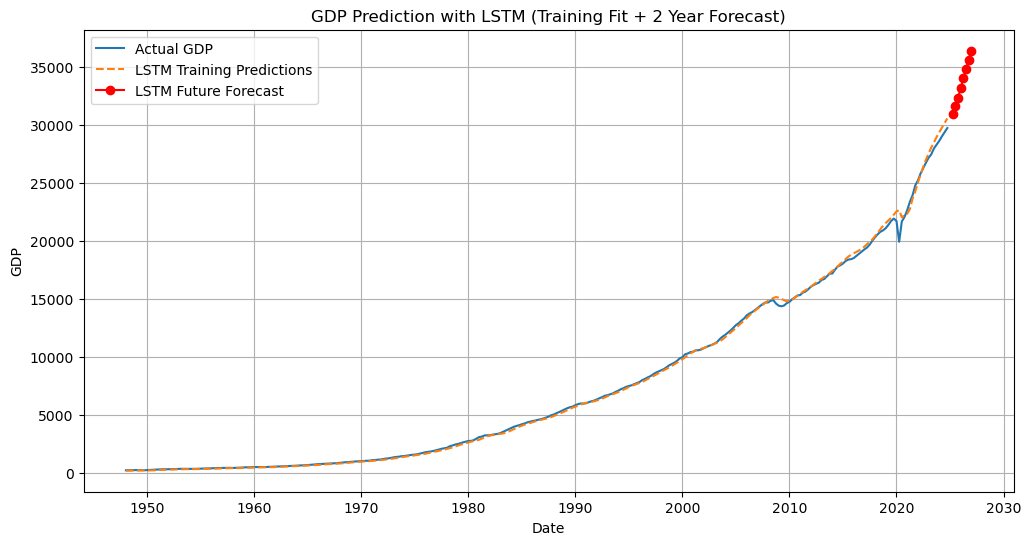

Model Summary:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 4, 50)             10400     
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 30651 (119.73 KB)
Trainable params: 30651 (119.73 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

Future Forecasts:
2025-Qq: 30927.22
2025-Qq: 31641.89
2025-Qq: 32348.19
2025-Qq: 33137.07
2026-Qq: 33992.70
2026-Qq: 34787.75
2026-Qq: 35581.28
2026-Qq: 36380.35


In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'data' is your DataFrame with 'GDP' column and datetime index
# Example data loading (uncomment if needed):
# data = pd.read_csv('your_data.csv', parse_dates=['Date'], index_col='Date')

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[['GDP']])

# Prepare the dataset for LSTM
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 4  # Use 4 quarters (1 year) as the time step
X, y = create_dataset(scaled_data, time_step)

# Reshape input to be [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X, y, epochs=100, batch_size=1, verbose=1)

# Predict on training data
train_predict = model.predict(X)
train_predict = scaler.inverse_transform(train_predict)  # Inverse transform to original scale

# Forecast future values
n_future = 8  # Number of quarters to predict (2 years)
future_forecast = []
last_sequence = scaled_data[-time_step:]  # Last known sequence
current_sequence = last_sequence.reshape(1, time_step, 1)

for i in range(n_future):
    next_pred = model.predict(current_sequence)
    future_forecast.append(next_pred[0,0])
    # Update the sequence with the new prediction (maintaining 3D shape)
    current_sequence = np.concatenate(
        (current_sequence[:,1:,:], 
         np.array([[[next_pred[0,0]]]])), 
        axis=1)

# Inverse transform future forecasts
future_forecast = scaler.inverse_transform(np.array(future_forecast).reshape(-1, 1))

# Create future dates
last_date = data.index[-1]
future_dates = pd.date_range(start=last_date, periods=n_future+1, freq='Q')[1:]

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(data.index[time_step:], data['GDP'][time_step:], label='Actual GDP')
plt.plot(data.index[time_step:], train_predict, label='LSTM Training Predictions', linestyle='--')
plt.plot(future_dates, future_forecast, 'ro-', label='LSTM Future Forecast')
plt.title('GDP Prediction with LSTM (Training Fit + 2 Year Forecast)')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.show()

# Print model summary
print("Model Summary:")
model.summary()

# Print some forecasted values
print("\nFuture Forecasts:")
for date, value in zip(future_dates, future_forecast):
    print(f"{date.strftime('%Y-Q%q')}: {value[0]:.2f}")

In [20]:
# Print model summary
model.summary()

# Train the model
model.fit(X, y, epochs=100, batch_size=1, verbose=1)

# Predict
train_predict = model.predict(X)
train_predict = scaler.inverse_transform(train_predict)  # Inverse transform to original scale

# Calculate RMSE for LSTM predictions
rmse_lstm = np.sqrt(mean_squared_error(data['GDP'][time_step:], train_predict))

# Calculate MSE for the SARIMA forecast
mse_forecast = mean_squared_error(data['GDP'][time_step:], train_predict)

# Calculate R-squared for the SARIMA forecast
r_squared_forecast = r2_score(data['GDP'][time_step:], train_predict)

mae = mean_absolute_error(data['GDP'][time_step:], train_predict)

# Print RMSE, MSE, and R-squared values
print(f"RMSE for LSTM Forecast: {rmse_lstm}")
print(f"MSE for LSTM Forecast: {mse_forecast}")
print(f"R-squared for LSTM Forecast: {r_squared_forecast}")
print(f"mae for LSTM Forecast: {mae}")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 4, 50)             10400     
                                                                 
 lstm_1 (LSTM)               (None, 50)                20200     
                                                                 
 dense (Dense)               (None, 1)                 51        
                                                                 
Total params: 30651 (119.73 KB)
Trainable params: 30651 (119.73 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/100
308/308 [==============================] - 0s 849us/step - loss: 1.1815e-04
Epoch 2/100
308/308 [==============================] - 0s 831us/step - loss: 1.2661e-04
Epoch 3/100
308/308 [==============================] - 0s 841us/step - loss: 1.6262e-04
Epoch 4/100
308/30

### GRU (Gated Recurrent Unit)

GRU is a simpler alternative to LSTM.

Epoch 1/100
308/308 [==============================] - 1s 880us/step - loss: 0.0042
Epoch 2/100
308/308 [==============================] - 0s 824us/step - loss: 2.2924e-04
Epoch 3/100
308/308 [==============================] - 0s 822us/step - loss: 2.3406e-04
Epoch 4/100
308/308 [==============================] - 0s 817us/step - loss: 5.7218e-04
Epoch 5/100
308/308 [==============================] - 0s 806us/step - loss: 8.9241e-04
Epoch 6/100
308/308 [==============================] - 0s 833us/step - loss: 1.6423e-04
Epoch 7/100
308/308 [==============================] - 0s 845us/step - loss: 2.2238e-04
Epoch 8/100
308/308 [==============================] - 0s 815us/step - loss: 2.5367e-04
Epoch 9/100
308/308 [==============================] - 0s 823us/step - loss: 1.7377e-04
Epoch 10/100
308/308 [==============================] - 0s 830us/step - loss: 4.5553e-04
Epoch 11/100
308/308 [==============================] - 0s 822us/step - loss: 2.2113e-04
Epoch 12/100
308/308 [============

/var/folders/kp/7yh5fxwj1g36fg94lthhd7n00000gn/T/ipykernel_11983/4048642899.py:58: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=last_date, periods=n_future+1, freq='Q')[1:]


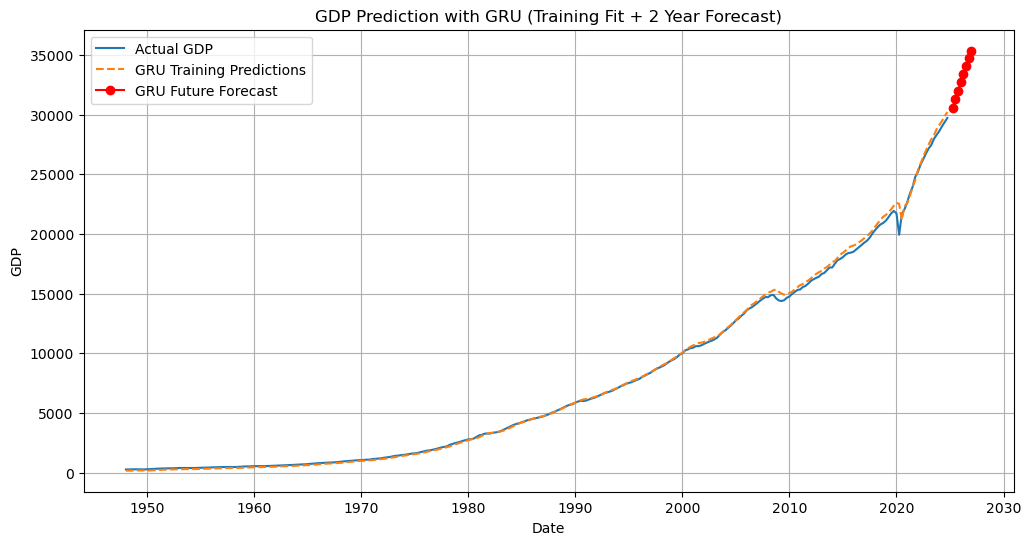

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 4, 50)             7950      
                                                                 
 gru_1 (GRU)                 (None, 50)                15300     
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 23301 (91.02 KB)
Trainable params: 23301 (91.02 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

Future GDP Forecasts:
2025-Qq: 30573.71
2025-Qq: 31329.18
2025-Qq: 32019.04
2025-Qq: 32706.82
2026-Qq: 33396.93
2026-Qq: 34071.88
2026-Qq: 34726.40
2026-Qq: 35359.26


In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[['GDP']])

# Prepare the dataset for GRU
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 4  # Use 4 quarters (1 year) as the time step
X, y = create_dataset(scaled_data, time_step)

# Reshape input to be [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# Build the GRU model
model = Sequential()
model.add(GRU(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(GRU(50, return_sequences=False))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X, y, epochs=100, batch_size=1, verbose=1)

# Predict on training data
train_predict = model.predict(X)
train_predict = scaler.inverse_transform(train_predict)

# Forecast future values
n_future = 8  # Number of quarters to predict (2 years)
future_forecast = []
last_sequence = scaled_data[-time_step:]  # Last known sequence
current_sequence = last_sequence.reshape(1, time_step, 1)

for i in range(n_future):
    next_pred = model.predict(current_sequence)
    future_forecast.append(next_pred[0,0])
    # Update the sequence with the new prediction
    current_sequence = np.concatenate((current_sequence[:,1:,:],np.array([[[next_pred[0,0]]]])),axis=1)

# Inverse transform future forecasts
future_forecast = scaler.inverse_transform(np.array(future_forecast).reshape(-1, 1))

# Create future dates
last_date = data.index[-1]
future_dates = pd.date_range(start=last_date, periods=n_future+1, freq='Q')[1:]

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(data.index[time_step:], data['GDP'][time_step:], label='Actual GDP')
plt.plot(data.index[time_step:], train_predict, label='GRU Training Predictions', linestyle='--')
plt.plot(future_dates, future_forecast, 'ro-', label='GRU Future Forecast')
plt.title('GDP Prediction with GRU (Training Fit + 2 Year Forecast)')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.show()

# Model summary
model.summary()

# Print forecasted values
print("\nFuture GDP Forecasts:")
for date, value in zip(future_dates, future_forecast):
    print(f"{date.strftime('%Y-Q%q')}: {value[0]:.2f}")

In [22]:
# Print model summary
model.summary()

# Train the model
model.fit(X, y, epochs=100, batch_size=1, verbose=1)

# Predict
train_predict = model.predict(X)
train_predict = scaler.inverse_transform(train_predict)  # Inverse transform to original scale

# Calculate RMSE for LSTM predictions
rmse_gru = np.sqrt(mean_squared_error(data['GDP'][time_step:], train_predict))

# Calculate MSE for the SARIMA forecast
mse_forecast = mean_squared_error(data['GDP'][time_step:], train_predict)

# Calculate R-squared for the SARIMA forecast
r_squared_forecast = r2_score(data['GDP'][time_step:], train_predict)

mae = mean_absolute_error(data['GDP'][time_step:], train_predict)

# Print RMSE, MSE, and R-squared values
print(f"RMSE for GRU Forecast: {rmse_gru}")
print(f"MSE for GRU Forecast: {mse_forecast}")
print(f"R-squared for GRU Forecast: {r_squared_forecast}")
print(f"mae for GRU Forecast: {mae}")

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 4, 50)             7950      
                                                                 
 gru_1 (GRU)                 (None, 50)                15300     
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 23301 (91.02 KB)
Trainable params: 23301 (91.02 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/100
308/308 [==============================] - 0s 846us/step - loss: 9.6363e-05
Epoch 2/100
308/308 [==============================] - 0s 835us/step - loss: 1.5206e-04
Epoch 3/100
308/308 [==============================] - 0s 916us/step - loss: 8.0931e-05
Epoch 4/100
308/30

### CNN (Convolutional Neural Networks)

CNN can be used for time series by treating the data as a 1D signal.

Epoch 1/100
308/308 [==============================] - 0s 296us/step - loss: 0.0069
Epoch 2/100
308/308 [==============================] - 0s 277us/step - loss: 1.1672e-04
Epoch 3/100
308/308 [==============================] - 0s 279us/step - loss: 1.7707e-04
Epoch 4/100
308/308 [==============================] - 0s 278us/step - loss: 1.9499e-04
Epoch 5/100
308/308 [==============================] - 0s 277us/step - loss: 1.7427e-04
Epoch 6/100
308/308 [==============================] - 0s 278us/step - loss: 1.2254e-04
Epoch 7/100
308/308 [==============================] - 0s 278us/step - loss: 1.8455e-04
Epoch 8/100
308/308 [==============================] - 0s 282us/step - loss: 1.3373e-04
Epoch 9/100
308/308 [==============================] - 0s 284us/step - loss: 1.7828e-04
Epoch 10/100
308/308 [==============================] - 0s 278us/step - loss: 3.0903e-04
Epoch 11/100
308/308 [==============================] - 0s 276us/step - loss: 1.0799e-04
Epoch 12/100
308/308 [============

/var/folders/kp/7yh5fxwj1g36fg94lthhd7n00000gn/T/ipykernel_11983/3353651501.py:63: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=last_date, periods=n_future+1, freq='Q')[1:]


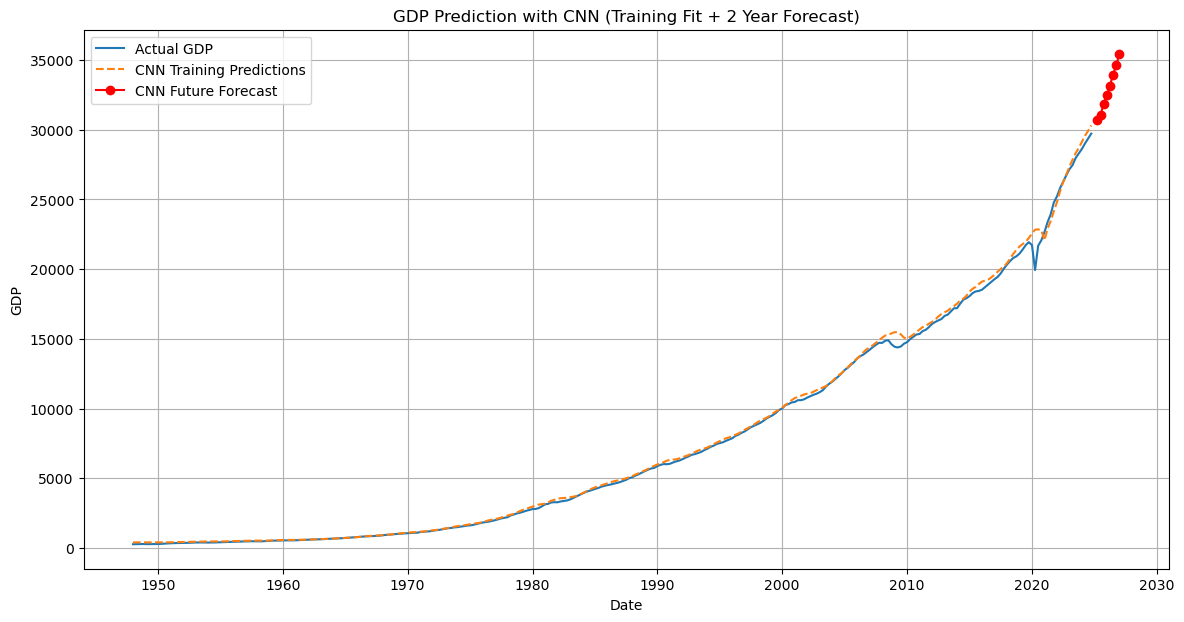

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 3, 64)             192       
                                                                 
 max_pooling1d (MaxPooling1  (None, 1, 64)             0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 50)                3250      
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 3493 (13.64 KB)
Trainable params: 3493 (13.64 KB)
Non-trainable params: 0 (0.00 Byte)
____________________

In [23]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[['GDP']])

# Prepare the dataset for CNN
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 4  # Use 4 quarters (1 year) as the time step
X, y = create_dataset(scaled_data, time_step)

# Reshape input to be [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# Build the CNN model
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(time_step, 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X, y, epochs=100, batch_size=1, verbose=1)

# Predict on training data
train_predict = model.predict(X)
train_predict = scaler.inverse_transform(train_predict)

# Forecast future values
n_future = 8  # Number of quarters to predict (2 years)
future_forecast = []
last_sequence = scaled_data[-time_step:]  # Last known sequence
current_sequence = last_sequence.reshape(1, time_step, 1)

for i in range(n_future):
    next_pred = model.predict(current_sequence)
    future_forecast.append(next_pred[0,0])
    # Update the sequence with the new prediction
    current_sequence = np.concatenate(
        (current_sequence[:,1:,:], 
        np.array([[[next_pred[0,0]]]])), 
        axis=1)

# Inverse transform future forecasts
future_forecast = scaler.inverse_transform(np.array(future_forecast).reshape(-1, 1))

# Create future dates
last_date = data.index[-1]
future_dates = pd.date_range(start=last_date, periods=n_future+1, freq='Q')[1:]

# Plot results
plt.figure(figsize=(14, 7))
plt.plot(data.index[time_step:], data['GDP'][time_step:], label='Actual GDP')
plt.plot(data.index[time_step:], train_predict, label='CNN Training Predictions', linestyle='--')
plt.plot(future_dates, future_forecast, 'ro-', label='CNN Future Forecast')
plt.title('GDP Prediction with CNN (Training Fit + 2 Year Forecast)')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.show()

# Model summary
model.summary()

# Print forecasted values
print("\nFuture GDP Forecasts:")
for date, value in zip(future_dates, future_forecast):
    print(f"{date.strftime('%Y-Q%q')}: {value[0]:.2f}")

In [24]:
# Print model summary
model.summary()

# Train the model
model.fit(X, y, epochs=100, batch_size=1, verbose=1)

# Predict
train_predict = model.predict(X)
train_predict = scaler.inverse_transform(train_predict)  # Inverse transform to original scale

# Calculate RMSE for CNN predictions
rmse_CNN = np.sqrt(mean_squared_error(data['GDP'][time_step:], train_predict))

# Calculate MSE for the CNN forecast
mse_forecast = mean_squared_error(data['GDP'][time_step:], train_predict)

# Calculate R-squared for the CNN forecast
r_squared_forecast = r2_score(data['GDP'][time_step:], train_predict)

mae = mean_absolute_error(data['GDP'][time_step:], train_predict)

# Print RMSE, MSE, and R-squared values
print(f"RMSE for GRU Forecast: {rmse_CNN}")
print(f"MSE for GRU Forecast: {mse_forecast}")
print(f"R-squared for GRU Forecast: {r_squared_forecast}")
print(f"mae for GRU Forecast: {mae}")

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 3, 64)             192       
                                                                 
 max_pooling1d (MaxPooling1  (None, 1, 64)             0         
 D)                                                              
                                                                 
 flatten (Flatten)           (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 50)                3250      
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 3493 (13.64 KB)
Trainable params: 3493 (13.64 KB)
Non-trainable params: 0 (0.00 Byte)
____________________

# Hybrid Model: ARIMA + LSTM

Epoch 1/100


/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


308/308 [==============================] - 1s 878us/step - loss: 0.0104
Epoch 2/100
308/308 [==============================] - 0s 831us/step - loss: 0.0028
Epoch 3/100
308/308 [==============================] - 0s 832us/step - loss: 0.0029
Epoch 4/100
308/308 [==============================] - 0s 837us/step - loss: 0.0027
Epoch 5/100
308/308 [==============================] - 0s 829us/step - loss: 0.0029
Epoch 6/100
308/308 [==============================] - 0s 828us/step - loss: 0.0028
Epoch 7/100
308/308 [==============================] - 0s 832us/step - loss: 0.0026
Epoch 8/100
308/308 [==============================] - 0s 844us/step - loss: 0.0025
Epoch 9/100
308/308 [==============================] - 0s 842us/step - loss: 0.0026
Epoch 10/100
308/308 [==============================] - 0s 824us/step - loss: 0.0027
Epoch 11/100
308/308 [==============================] - 0s 830us/step - loss: 0.0025
Epoch 12/100
308/308 [==============================] - 0s 827us/step - loss: 0.0025
E

/var/folders/kp/7yh5fxwj1g36fg94lthhd7n00000gn/T/ipykernel_11983/4026724722.py:85: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(


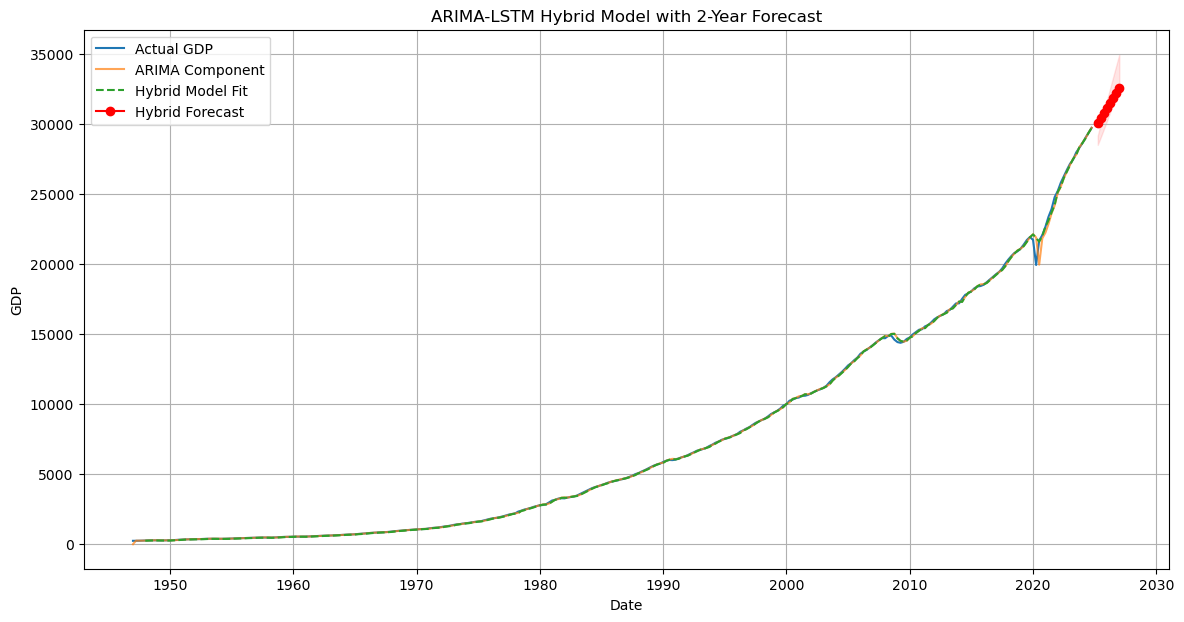


Hybrid Model Forecast Results:
-----------------------------
2025-Qq: 30064.46 (ARIMA: 30079.51, LSTM Residual: -15.05)
2025-Qq: 30418.90 (ARIMA: 30434.61, LSTM Residual: -15.71)
2025-Qq: 30774.24 (ARIMA: 30789.17, LSTM Residual: -14.93)
2025-Qq: 31128.63 (ARIMA: 31143.20, LSTM Residual: -14.57)
2026-Qq: 31482.25 (ARIMA: 31496.69, LSTM Residual: -14.45)
2026-Qq: 31835.20 (ARIMA: 31849.65, LSTM Residual: -14.45)
2026-Qq: 32187.60 (ARIMA: 32202.07, LSTM Residual: -14.48)
2026-Qq: 32539.48 (ARIMA: 32553.96, LSTM Residual: -14.49)


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load your data (assuming 'data' is a DataFrame with 'GDP' column and datetime index)
# data = pd.read_csv('your_data.csv', parse_dates=['Date'], index_col='Date')

# 1. ARIMA Component ======================================================
arima_model = ARIMA(data['GDP'], order=(1, 1, 1))  # Your ARIMA configuration
arima_results = arima_model.fit()

# Get ARIMA predictions
arima_predictions = arima_results.predict(start=0, end=len(data)-1)

# Calculate residuals (non-linear components)
residuals = data['GDP'] - arima_predictions

# 2. LSTM Component (for residuals) =======================================
# Normalize residuals
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_residuals = scaler.fit_transform(residuals.values.reshape(-1, 1))

# Prepare dataset for LSTM
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data)-time_step):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 4  # 4 quarters = 1 year
X, y = create_dataset(scaled_residuals, time_step)

# Reshape input to be [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# Build LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
lstm_model.add(LSTM(50, return_sequences=False))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Train LSTM model
lstm_model.fit(X, y, epochs=100, batch_size=1, verbose=1)

# Predict residuals using LSTM
lstm_predictions = lstm_model.predict(X)
lstm_predictions = scaler.inverse_transform(lstm_predictions)

# 3. Hybrid Forecast ======================================================
forecast_steps = 8  # Forecast next 8 quarters (2 years)

# ARIMA forecast
arima_forecast = arima_results.get_forecast(steps=forecast_steps)
arima_fc_values = arima_forecast.predicted_mean
arima_conf_int = arima_forecast.conf_int()

# LSTM residual forecast
future_residuals = []
last_seq = scaled_residuals[-time_step:]  # Last available residual sequence
current_seq = last_seq.reshape(1, time_step, 1)

for i in range(forecast_steps):
    next_res = lstm_model.predict(current_seq, verbose=0)[0,0]
    future_residuals.append(next_res)
    current_seq = np.concatenate(
        [current_seq[:,1:,:], 
         np.array([[[next_res]]])],
        axis=1
    )

future_residuals = scaler.inverse_transform(np.array(future_residuals).reshape(-1, 1)).flatten()

# Combine forecasts
hybrid_forecast = arima_fc_values + future_residuals

# 4. Visualization ========================================================
# Generate future dates
last_date = data.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=3),  # Next quarter
    periods=forecast_steps,
    freq='Q'
)

plt.figure(figsize=(14, 7))
plt.plot(data.index, data['GDP'], label='Actual GDP')
plt.plot(data.index, arima_predictions, label='ARIMA Component', alpha=0.7)
plt.plot(data.index[time_step:], arima_predictions[time_step:] + lstm_predictions.flatten(), 
         label='Hybrid Model Fit', linestyle='--')
plt.plot(future_dates, hybrid_forecast, 'ro-', label='Hybrid Forecast')
plt.fill_between(future_dates,
                arima_fc_values + arima_conf_int.iloc[:,0] - arima_fc_values.mean(),
                arima_fc_values + arima_conf_int.iloc[:,1] - arima_fc_values.mean(),
                color='red', alpha=0.1)
plt.title('ARIMA-LSTM Hybrid Model with 2-Year Forecast')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.show()

# 5. Print Forecast Results ===============================================
print("\nHybrid Model Forecast Results:")
print("-----------------------------")
for date, fc, arima_part, residual_part in zip(future_dates, hybrid_forecast, arima_fc_values, future_residuals):
    print(f"{date.strftime('%Y-Q%q')}: {fc:.2f} (ARIMA: {arima_part:.2f}, LSTM Residual: {residual_part:.2f})")

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

# ... [keep all your previous code until after the LSTM predictions] ...

# Calculate hybrid model predictions on training data
hybrid_train_predictions = arima_predictions[time_step:] + lstm_predictions.flatten()
actual_values = data['GDP'][time_step:]

# Calculate metrics
mse = mean_squared_error(actual_values, hybrid_train_predictions)
mae = mean_absolute_error(actual_values, hybrid_train_predictions)
r2 = r2_score(actual_values, hybrid_train_predictions)
rmse = math.sqrt(mse)

print('\nModel Performance Metrics:')
print('-------------------------')
print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}') 
print(f'R-squared: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')

# ... [continue with the rest of your forecasting code] ...


Model Performance Metrics:
-------------------------
MSE: 17889.2170
MAE: 51.3385
R-squared: 0.9997
RMSE: 133.7506


# Hybrid Model: ARIMA + GRU

/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


Epoch 1/100
308/308 [==============================] - 1s 1ms/step - loss: 0.0087
Epoch 2/100
308/308 [==============================] - 1s 2ms/step - loss: 0.0030
Epoch 3/100
308/308 [==============================] - 0s 970us/step - loss: 0.0030
Epoch 4/100
308/308 [==============================] - 0s 877us/step - loss: 0.0029
Epoch 5/100
308/308 [==============================] - 0s 824us/step - loss: 0.0029
Epoch 6/100
308/308 [==============================] - 0s 800us/step - loss: 0.0028
Epoch 7/100
308/308 [==============================] - 0s 792us/step - loss: 0.0026
Epoch 8/100
308/308 [==============================] - 0s 790us/step - loss: 0.0027
Epoch 9/100
308/308 [==============================] - 0s 796us/step - loss: 0.0026
Epoch 10/100
308/308 [==============================] - 0s 807us/step - loss: 0.0025
Epoch 11/100
308/308 [==============================] - 0s 798us/step - loss: 0.0026
Epoch 12/100
308/308 [==============================] - 0s 825us/step - loss: 

/var/folders/kp/7yh5fxwj1g36fg94lthhd7n00000gn/T/ipykernel_11983/2026540136.py:96: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(


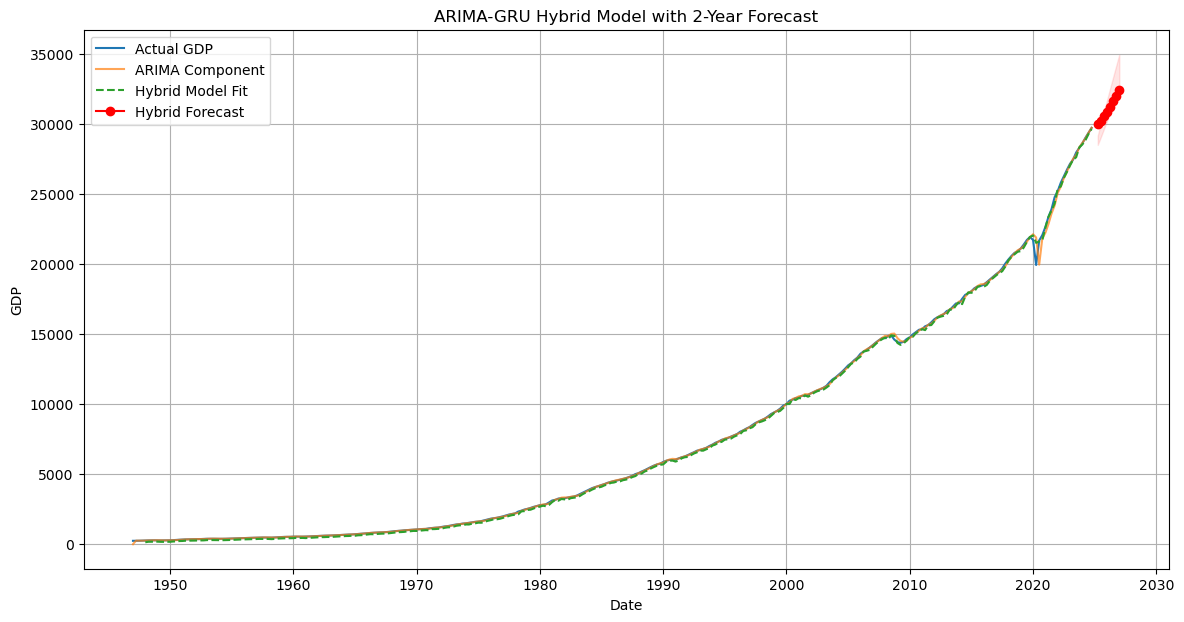


Hybrid Forecast Results:
-----------------------
2025-Qq: 29974.65
2025-Qq: 30249.71
2025-Qq: 30548.03
2025-Qq: 30878.09
2026-Qq: 31245.56
2026-Qq: 31631.66
2026-Qq: 32020.41
2026-Qq: 32399.39


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

# Load data (assuming 'data' is a DataFrame with 'GDP' column and datetime index)
# data = pd.read_csv('your_data.csv', parse_dates=['Date'], index_col='Date')

# 1. ARIMA Component ======================================================
arima_model = ARIMA(data['GDP'], order=(1, 1, 1))
arima_results = arima_model.fit()
arima_predictions = arima_results.predict(start=0, end=len(data)-1)

# Calculate residuals
residuals = data['GDP'] - arima_predictions

# 2. GRU Component (for residuals) ========================================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_residuals = scaler.fit_transform(residuals.values.reshape(-1, 1))

def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data)-time_step):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 4
X, y = create_dataset(scaled_residuals, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Build GRU model
gru_model = Sequential()
gru_model.add(GRU(50, return_sequences=True, input_shape=(time_step, 1)))
gru_model.add(GRU(50, return_sequences=False))
gru_model.add(Dense(1))
gru_model.compile(optimizer='adam', loss='mean_squared_error')

# Train GRU model
gru_model.fit(X, y, epochs=100, batch_size=1, verbose=1)

# Predict residuals using GRU
gru_predictions = gru_model.predict(X)
gru_predictions = scaler.inverse_transform(gru_predictions)

# 3. Performance Metrics ==================================================
hybrid_train_predictions = arima_predictions[time_step:] + gru_predictions.flatten()
actual_values = data['GDP'][time_step:]

mse = mean_squared_error(actual_values, hybrid_train_predictions)
mae = mean_absolute_error(actual_values, hybrid_train_predictions)
r2 = r2_score(actual_values, hybrid_train_predictions)
rmse = math.sqrt(mse)

print('\nModel Performance Metrics:')
print('-------------------------')
print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R-squared: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')

# 4. Forecasting ==========================================================
forecast_steps = 8  # 8 quarters = 2 years

# ARIMA forecast
arima_forecast = arima_results.get_forecast(steps=forecast_steps)
arima_fc_values = arima_forecast.predicted_mean
arima_conf_int = arima_forecast.conf_int()

# GRU residual forecast
future_residuals = []
last_seq = scaled_residuals[-time_step:]
current_seq = last_seq.reshape(1, time_step, 1)

for i in range(forecast_steps):
    next_res = gru_model.predict(current_seq, verbose=0)[0,0]
    future_residuals.append(next_res)
    current_seq = np.concatenate(
        [current_seq[:,1:,:], 
        np.array([[[next_res]]])],
        axis=1
    )

future_residuals = scaler.inverse_transform(np.array(future_residuals).reshape(-1, 1)).flatten()

# Combine forecasts
hybrid_forecast = arima_fc_values + future_residuals

# 5. Visualization ========================================================
last_date = data.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=3),
    periods=forecast_steps,
    freq='Q'
)

plt.figure(figsize=(14, 7))
plt.plot(data.index, data['GDP'], label='Actual GDP')
plt.plot(data.index, arima_predictions, label='ARIMA Component', alpha=0.7)
plt.plot(data.index[time_step:], hybrid_train_predictions, 
         label='Hybrid Model Fit', linestyle='--')
plt.plot(future_dates, hybrid_forecast, 'ro-', label='Hybrid Forecast')
plt.fill_between(future_dates,
                arima_fc_values + arima_conf_int.iloc[:,0] - arima_fc_values.mean(),
                arima_fc_values + arima_conf_int.iloc[:,1] - arima_fc_values.mean(),
                color='red', alpha=0.1)
plt.title('ARIMA-GRU Hybrid Model with 2-Year Forecast')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.show()

# 6. Forecast Results =====================================================
print("\nHybrid Forecast Results:")
print("-----------------------")
for date, fc in zip(future_dates, hybrid_forecast):
    print(f"{date.strftime('%Y-Q%q')}: {fc:.2f}")

# Hybrid Model: ARIMA + CNN

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

# Load data (assuming 'data' is a DataFrame with 'GDP' column and datetime index)
# data = pd.read_csv('your_data.csv', parse_dates=['Date'], index_col='Date')

# 1. ARIMA Component ======================================================
arima_model = ARIMA(data['GDP'], order=(1, 1, 1))
arima_results = arima_model.fit()
arima_predictions = arima_results.predict(start=0, end=len(data)-1)

# Calculate residuals
residuals = data['GDP'] - arima_predictions

# 2. CNN Component (for residuals) ========================================
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_residuals = scaler.fit_transform(residuals.values.reshape(-1, 1))

def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data)-time_step):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 4
X, y = create_dataset(scaled_residuals, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Build CNN model
cnn_model = Sequential()
cnn_model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(time_step, 1)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Flatten())
cnn_model.add(Dense(50, activation='relu'))
cnn_model.add(Dense(1))
cnn_model.compile(optimizer='adam', loss='mean_squared_error')

# Train CNN model
cnn_model.fit(X, y, epochs=100, batch_size=1, verbose=1)

# Predict residuals using CNN
cnn_predictions = cnn_model.predict(X)
cnn_predictions = scaler.inverse_transform(cnn_predictions)

# 3. Performance Metrics =================================================
hybrid_train_predictions = arima_predictions[time_step:] + cnn_predictions.flatten()
actual_values = data['GDP'][time_step:]

mse = mean_squared_error(actual_values, hybrid_train_predictions)
mae = mean_absolute_error(actual_values, hybrid_train_predictions)
r2 = r2_score(actual_values, hybrid_train_predictions)
rmse = math.sqrt(mse)

print('\nModel Performance Metrics:')
print('-------------------------')
print(f'MSE: {mse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R-squared: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')

# 4. Forecasting =========================================================
forecast_steps = 8  # 8 quarters = 2 years

# ARIMA forecast
arima_forecast = arima_results.get_forecast(steps=forecast_steps)
arima_fc_values = arima_forecast.predicted_mean
arima_conf_int = arima_forecast.conf_int()

# CNN residual forecast
future_residuals = []
last_seq = scaled_residuals[-time_step:]
current_seq = last_seq.reshape(1, time_step, 1)

for i in range(forecast_steps):
    next_res = cnn_model.predict(current_seq, verbose=0)[0,0]
    future_residuals.append(next_res)
    # Update sequence (shift window)
    current_seq = np.concatenate(
        [current_seq[:,1:,:], 
         np.array([[[next_res]]])],
        axis=1
    )

future_residuals = scaler.inverse_transform(np.array(future_residuals).reshape(-1, 1)).flatten()

# Combine forecasts
hybrid_forecast = arima_fc_values + future_residuals

# 5. Visualization =======================================================
last_date = data.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=3),
    periods=forecast_steps,
    freq='Q'
)

plt.figure(figsize=(14, 7))
plt.plot(data.index, data['GDP'], label='Actual GDP')
plt.plot(data.index, arima_predictions, label='ARIMA Component', alpha=0.7)
plt.plot(data.index[time_step:], hybrid_train_predictions, 
         label='Hybrid Model Fit', linestyle='--')
plt.plot(future_dates, hybrid_forecast, 'ro-', label='Hybrid Forecast')
plt.fill_between(future_dates,
                arima_fc_values + arima_conf_int.iloc[:,0] - arima_fc_values.mean(),
                arima_fc_values + arima_conf_int.iloc[:,1] - arima_fc_values.mean(),
                color='red', alpha=0.1)
plt.title('ARIMA-CNN Hybrid Model with 2-Year Forecast')
plt.xlabel('Date')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.show()

# 6. Forecast Results ====================================================
print("\nHybrid Forecast Results:")
print("-----------------------")
for date, fc in zip(future_dates, hybrid_forecast):
    print(f"{date.strftime('%Y-Q%q')}: {fc:.2f}")

Epoch 1/100


/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/Users/someswararaotarra/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


308/308 [==============================] - 0s 316us/step - loss: 0.0064
Epoch 2/100
308/308 [==============================] - 0s 294us/step - loss: 0.0027
Epoch 3/100
308/308 [==============================] - 0s 291us/step - loss: 0.0026
Epoch 4/100
308/308 [==============================] - 0s 289us/step - loss: 0.0025
Epoch 5/100
308/308 [==============================] - 0s 289us/step - loss: 0.0025
Epoch 6/100
308/308 [==============================] - 0s 286us/step - loss: 0.0025
Epoch 7/100
308/308 [==============================] - 0s 286us/step - loss: 0.0025
Epoch 8/100
308/308 [==============================] - 0s 285us/step - loss: 0.0024
Epoch 9/100
308/308 [==============================] - 0s 285us/step - loss: 0.0024
Epoch 10/100
308/308 [==============================] - 0s 284us/step - loss: 0.0026
Epoch 11/100
308/308 [==============================] - 0s 285us/step - loss: 0.0024
Epoch 12/100
308/308 [==============================] - 0s 282us/step - loss: 0.0024
E